<a href="https://colab.research.google.com/github/konyaslcuklu42-beep/Yapay-zeka/blob/main/Colab'e_ho%C5%9F_geldiniz_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Veri setini online kaynaktan çekiyoruz
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"]
df = pd.read_csv(url, names=columns, na_values="?")

print("Veri seti başarıyla yüklendi. İlk 5 satır:")
print(df.head())

Veri seti başarıyla yüklendi. İlk 5 satır:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  


/tmp/ipykernel_13337/4094532933.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='magma')


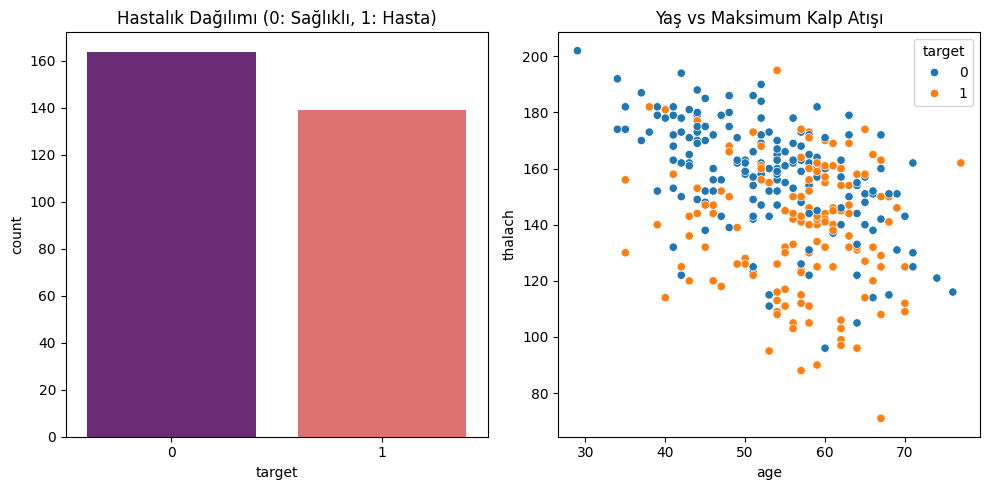

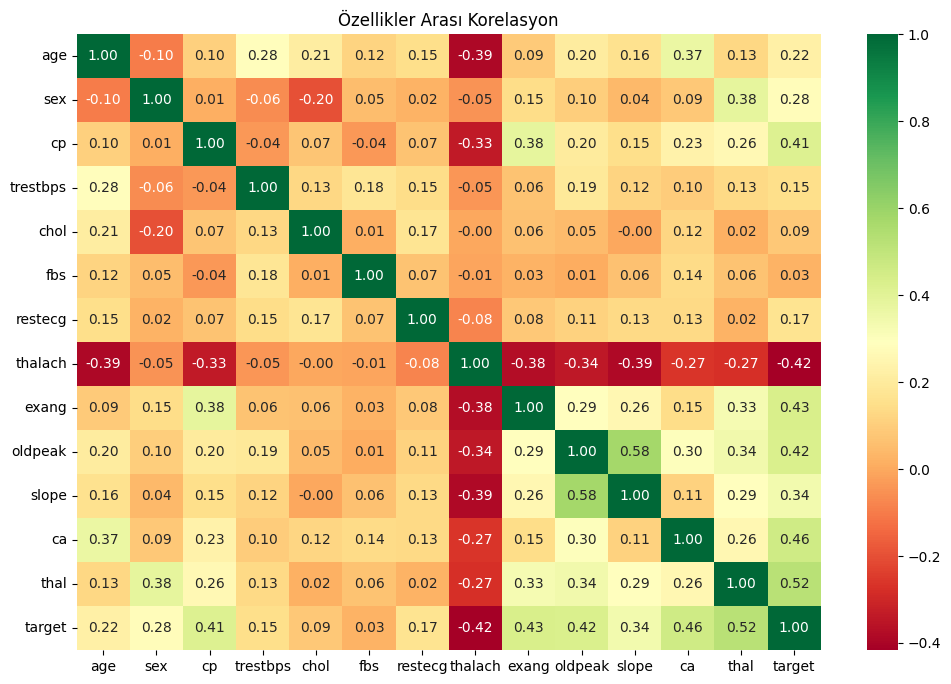

In [11]:
# --- Veri Temizleme ---
# Eksik verileri (NaN) sütun ortalaması ile dolduralım
df = df.fillna(df.median())

# Hedef değişkeni ikili sınıfa çevirelim (0: Sağlıklı, 1: Hasta)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# --- Görselleştirme (EDA) ---
plt.figure(figsize=(10, 5))

# 1. Grafik: Hastalık Dağılımı
plt.subplot(1, 2, 1)
sns.countplot(x='target', data=df, palette='magma', hue='target', legend='False')
plt.title("Hastalık Dağılımı (0: Sağlıklı, 1: Hasta)")

# 2. Grafik: Yaş ve Kalp Atış Hızı İlişkisi
plt.subplot(1, 2, 2)
sns.scatterplot(x='age', y='thalach', hue='target', data=df)
plt.title("Yaş vs Maksimum Kalp Atışı")

plt.tight_layout()
plt.show()

# Korelasyon Matrisi (Hangi özellik hedefle daha ilişkili?)
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title("Özellikler Arası Korelasyon")
plt.show()

In [12]:
# Veriyi özellikler (X) ve hedef (y) olarak ayıralım
X = df.drop('target', axis=1)
y = df['target']

# Veriyi Eğitim ve Test seti olarak bölüyoruz (%20 Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirme (Modelin daha hızlı ve doğru öğrenmesi için)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Modelin oluşturulması ve eğitilmesi
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model başarıyla eğitildi!")

Model başarıyla eğitildi!


--- Model Değerlendirme Sonuçları ---
Doğruluk (Accuracy) Skoru: 0.87

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        29
           1       0.90      0.84      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



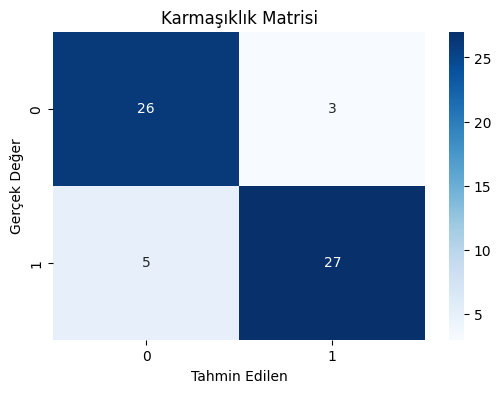

In [13]:
# Tahmin yapma
y_pred = model.predict(X_test)

# Sonuçları yazdırma
print("--- Model Değerlendirme Sonuçları ---")
print(f"Doğruluk (Accuracy) Skoru: {accuracy_score(y_test, y_pred):.2f}")
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))

# Karmaşıklık Matrisi (Confusion Matrix) Görselleştirme
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Karmaşıklık Matrisi')
plt.show()